In [ ]:
%pip install -r ./../stellar_classification/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = './star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

display(star.head())


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    label_encoder,
    scaler,
    feature_names,
    pca,
) = sc.prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [4]:
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# ============================================================
# Neural Network setup
# ============================================================

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

Input size: 13
Number of classes: 3


In [6]:
# ============================================================
# Import experiment runner
# ============================================================

from stellar_classification.experiments.nn_runner import run_experiments

In [7]:
# ============================================================
# Run Neural Network Experiments
# ============================================================

results_df = run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=15,
)


Training SimpleNN | lr=0.01
Epoch 1/15 | loss=0.4354 | train_acc=83.67% | val_acc=85.33%
Epoch 2/15 | loss=0.3889 | train_acc=85.33% | val_acc=84.09%
Epoch 3/15 | loss=0.3752 | train_acc=85.77% | val_acc=87.35%
Epoch 4/15 | loss=0.3672 | train_acc=86.24% | val_acc=83.32%
Epoch 5/15 | loss=0.3616 | train_acc=86.40% | val_acc=86.85%
Epoch 6/15 | loss=0.3557 | train_acc=86.60% | val_acc=83.03%
Epoch 7/15 | loss=0.3530 | train_acc=86.70% | val_acc=86.68%
Epoch 8/15 | loss=0.3513 | train_acc=86.87% | val_acc=82.75%
Epoch 9/15 | loss=0.3486 | train_acc=86.89% | val_acc=85.70%
Epoch 10/15 | loss=0.3489 | train_acc=86.90% | val_acc=86.97%
Epoch 11/15 | loss=0.3453 | train_acc=87.19% | val_acc=88.01%
Epoch 12/15 | loss=0.3454 | train_acc=87.13% | val_acc=83.26%
Epoch 13/15 | loss=0.3446 | train_acc=87.19% | val_acc=87.47%
Epoch 14/15 | loss=0.3447 | train_acc=87.24% | val_acc=87.97%
Epoch 15/15 | loss=0.3418 | train_acc=87.19% | val_acc=88.68%
✔ Done: SimpleNN | lr=0.01 | loss=0.3418 | train_a

In [10]:
# ============================================================
# Results
# ============================================================

display(results_df)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history
8,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.275719,89.594155,89.565646,90.023910,0.900092,89.565646,0.868195,89.636852,0.867598,"{'train_loss': [0.46873782839363315, 0.3686839..."
7,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.201549,92.394262,89.258914,93.410421,0.934115,89.258914,0.864694,89.313688,0.865294,"{'train_loss': [0.3908053100718113, 0.33251841..."
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.280332,89.422046,88.875500,89.771416,0.897688,88.875500,0.862502,89.132935,0.864995,"{'train_loss': [0.43260928367656865, 0.3577639..."
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.303535,88.555322,88.902887,89.023209,0.890032,88.902887,0.861332,89.527305,0.868484,"{'train_loss': [0.40441281573899734, 0.3556974..."
6,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.313057,88.465661,88.552336,89.076799,0.890678,88.552336,0.857802,88.804294,0.861079,"{'train_loss': [0.4191855201417864, 0.36223113..."
1,SimpleNN,0.0010,SimpleNN(\n (net): Sequential(\n (0): Line...,0.330823,87.615426,88.612587,87.791656,0.877485,88.612587,0.856764,88.798817,0.858706,"{'train_loss': [0.49387193818919817, 0.4202886..."
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.341822,87.190824,88.683793,87.404155,0.873524,88.683793,0.856207,88.875500,0.859199,"{'train_loss': [0.4354271243277866, 0.38890558..."
5,MediumNN,0.0001,MediumNN(\n (net): Sequential(\n (0): Line...,0.343941,86.958941,88.015556,87.065092,0.870149,88.015556,0.849820,88.322287,0.853151,"{'train_loss': [0.6338335862266601, 0.46045908..."
2,SimpleNN,0.0001,SimpleNN(\n (net): Sequential(\n (0): Line...,0.410731,84.843145,85.868434,84.896735,0.848311,85.868434,0.826385,86.054664,0.828171,"{'train_loss': [0.7211174707744337, 0.54580854..."


In [11]:
from stellar_classification.visualization.nn_plots import plot_training_history

In [12]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]

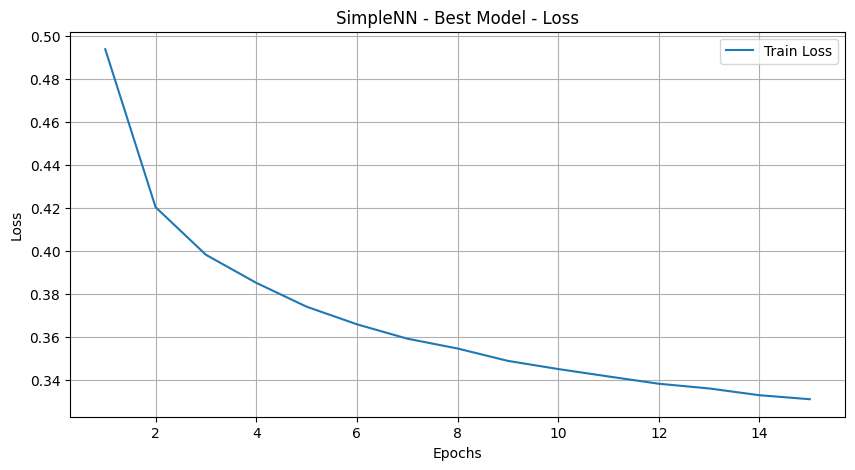

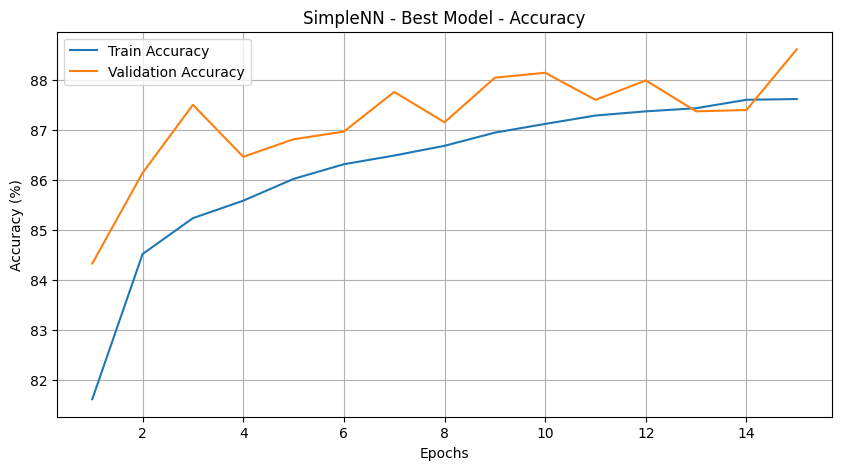

In [13]:
plot_training_history(best_simple["history"], title="SimpleNN - Best Model")

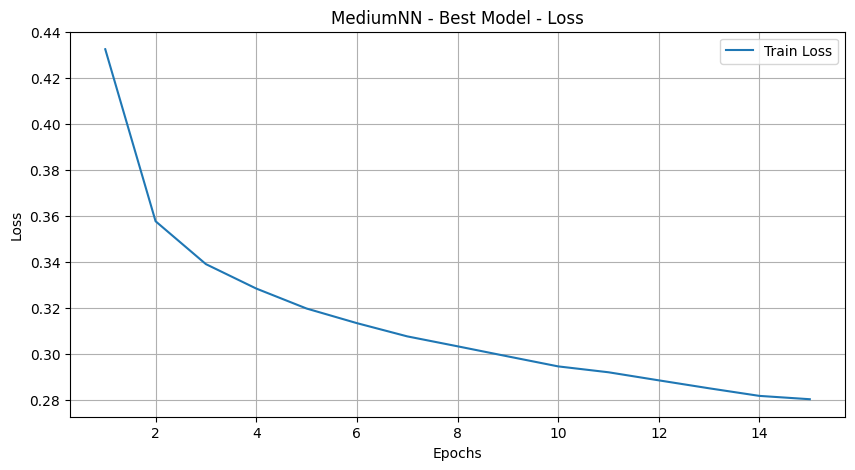

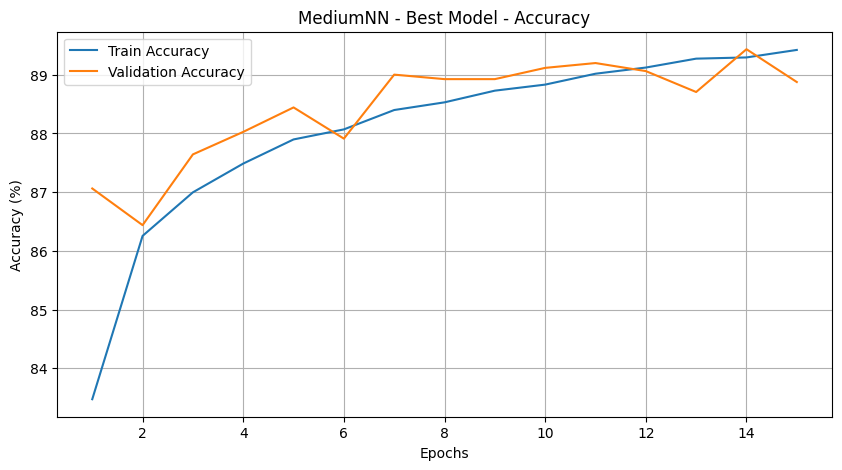

In [14]:
plot_training_history(best_medium["history"], title="MediumNN - Best Model")

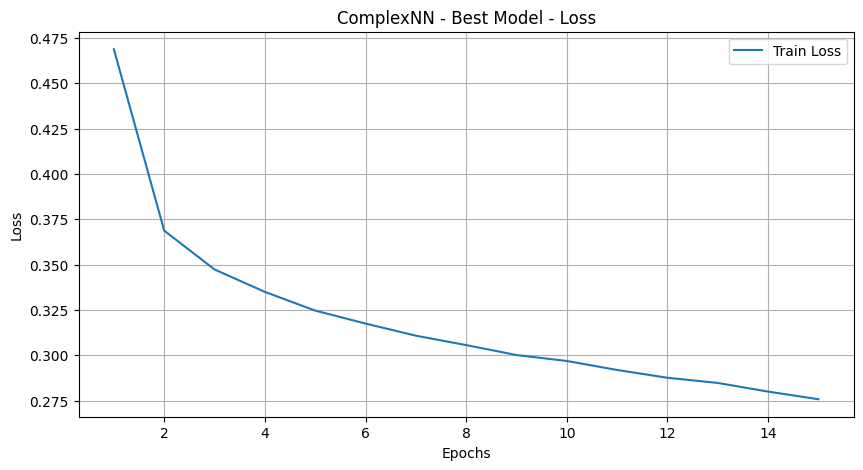

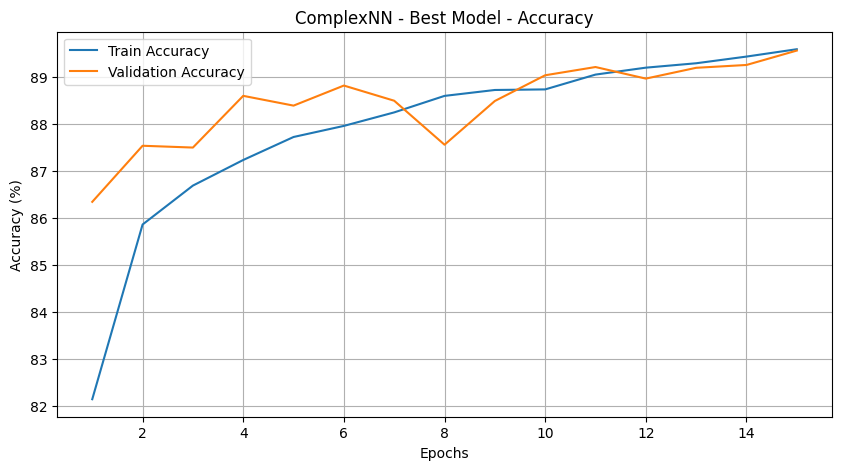

In [15]:
plot_training_history(best_complex["history"], title="ComplexNN - Best Model")

In [16]:
dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=15,
)


Best configuration for MediumNN: lr=0.001 | val_f1=0.8625

Dropout test → MediumNN | lr=0.001 | dropout=0.2
Epoch 1/15 | loss=0.4682 | train_acc=81.93% | val_acc=86.59%
Epoch 2/15 | loss=0.3913 | train_acc=85.02% | val_acc=87.53%
Epoch 3/15 | loss=0.3740 | train_acc=85.67% | val_acc=88.38%
Epoch 4/15 | loss=0.3607 | train_acc=86.20% | val_acc=88.32%
Epoch 5/15 | loss=0.3536 | train_acc=86.56% | val_acc=88.71%
Epoch 6/15 | loss=0.3477 | train_acc=86.70% | val_acc=88.39%
Epoch 7/15 | loss=0.3424 | train_acc=86.85% | val_acc=88.72%
Epoch 8/15 | loss=0.3392 | train_acc=87.06% | val_acc=89.26%
Epoch 9/15 | loss=0.3362 | train_acc=87.23% | val_acc=89.13%
Epoch 10/15 | loss=0.3338 | train_acc=87.41% | val_acc=89.06%
Epoch 11/15 | loss=0.3307 | train_acc=87.50% | val_acc=89.17%
Epoch 12/15 | loss=0.3270 | train_acc=87.54% | val_acc=89.31%
Epoch 13/15 | loss=0.3258 | train_acc=87.67% | val_acc=89.00%
Epoch 14/15 | loss=0.3221 | train_acc=87.72% | val_acc=88.75%
Epoch 15/15 | loss=0.3225 | trai

In [17]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

,model,learning_rate,dropout,trained_model,final_loss,final_train_acc,final_val_acc,val_accuracy,val_f1,test_accuracy,test_f1,history
0,MediumNN,0.0010,0.2,MediumNN(\n (net): Sequential(\n (0): Line...,0.322513,87.744249,89.406803,89.406803,0.866189,89.779263,0.870119,"{'train_loss': [0.4682213784580413, 0.39125939..."
1,MediumNN,0.0010,0.3,MediumNN(\n (net): Sequential(\n (0): Line...,0.342179,87.002226,89.313688,89.313688,0.865189,89.620420,0.868648,"{'train_loss': [0.49137214243647764, 0.4087066..."
4,ComplexNN,0.0001,0.3,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.333683,87.294913,88.963137,88.963137,0.862312,89.423235,0.867513,"{'train_loss': [0.5636161015017219, 0.42894791..."
3,ComplexNN,0.0001,0.2,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.317955,87.997774,88.804294,88.804294,0.861358,89.204141,0.865112,"{'train_loss': [0.5253992689406314, 0.40838767..."
2,MediumNN,0.0010,0.5,MediumNN(\n (net): Sequential(\n (0): Line...,0.387017,85.437794,88.601632,88.601632,0.855009,88.842636,0.858199,"{'train_loss': [0.5460917828856288, 0.45342078..."
5,ComplexNN,0.0001,0.5,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.376295,85.796438,88.377061,88.377061,0.853340,88.798817,0.858134,"{'train_loss': [0.6753434208992208, 0.50735368..."


In [18]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

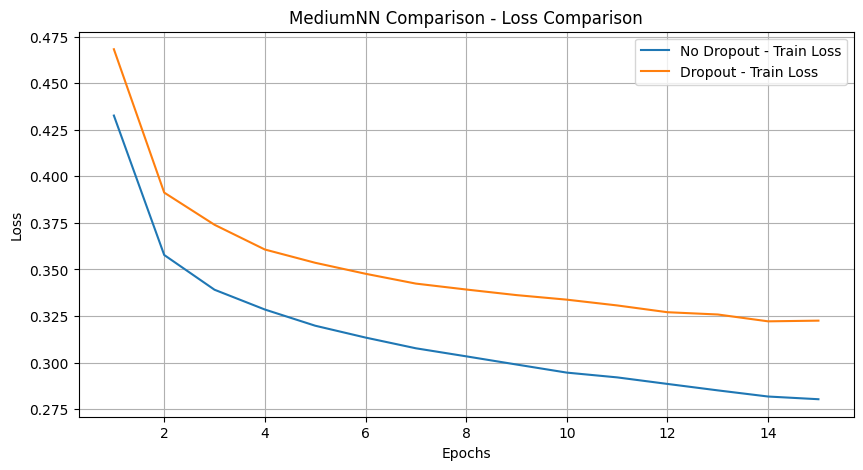

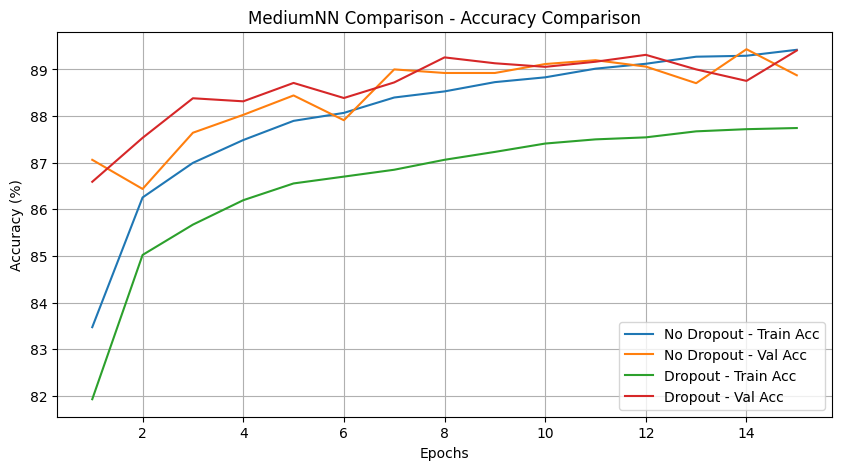

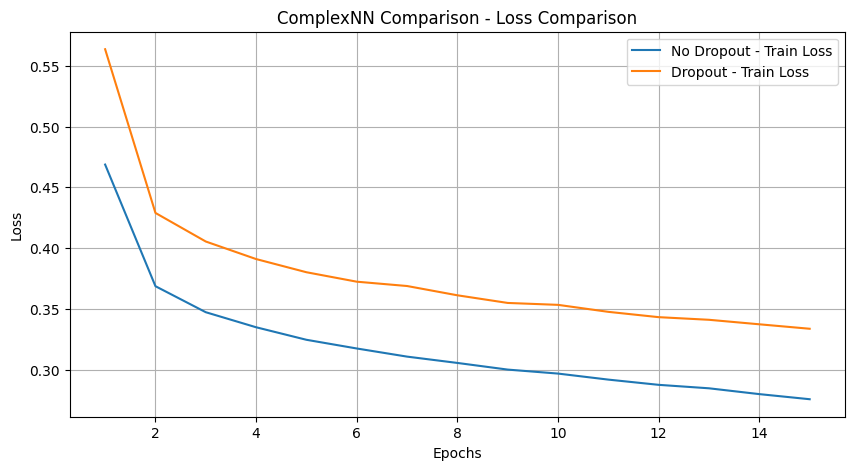

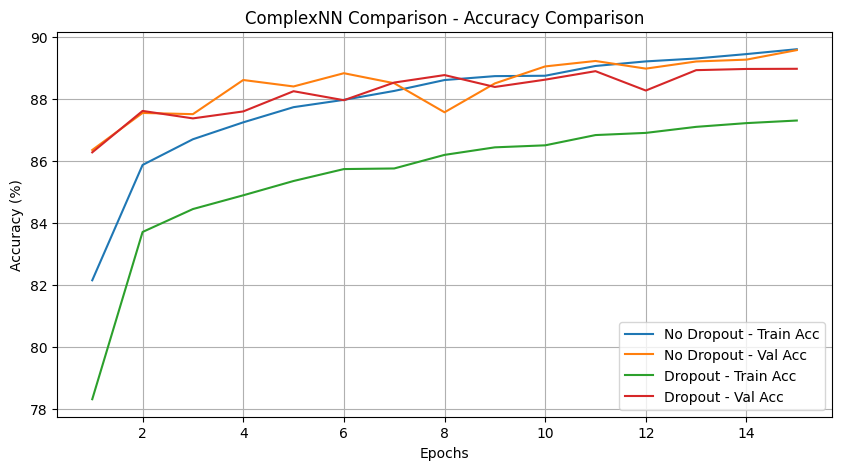

In [19]:
from stellar_classification.visualization.nn_plots import plot_dropout_comparison

plot_dropout_comparison(
    best_medium["history"],
    best_medium_dropout["history"],
    title="MediumNN Comparison"
)

plot_dropout_comparison(
    best_complex["history"],
    best_complex_dropout["history"],
    title="ComplexNN Comparison"
)

In [20]:
from stellar_classification.visualization.model_selection import get_final_candidates

final_sorted = get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history,dropout
0,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.275719,89.594155,89.565646,90.023910,0.900092,89.565646,0.868195,89.636852,0.867598,"{'train_loss': [0.46873782839363315, 0.3686839...",NaN
3,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.322513,87.744249,89.406803,NaN,NaN,89.406803,0.866189,89.779263,0.870119,"{'train_loss': [0.4682213784580413, 0.39125939...",0.2
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.342179,87.002226,89.313688,NaN,NaN,89.313688,0.865189,89.620420,0.868648,"{'train_loss': [0.49137214243647764, 0.4087066...",0.3
1,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.201549,92.394262,89.258914,93.410421,0.934115,89.258914,0.864694,89.313688,0.865294,"{'train_loss': [0.3908053100718113, 0.33251841...",NaN
2,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.280332,89.422046,88.875500,89.771416,0.897688,88.875500,0.862502,89.132935,0.864995,"{'train_loss': [0.43260928367656865, 0.3577639...",NaN
5,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.333683,87.294913,88.963137,NaN,NaN,88.963137,0.862312,89.423235,0.867513,"{'train_loss': [0.5636161015017219, 0.42894791...",0.3



ComplexNN:
  Accuracy  : 89.64%
  Precision: 0.8626
  Recall   : 0.8735
  F1       : 0.8676
  Confusion Matrix:
[[10065   362   354]
 [  232  3041   275]
 [  247   422  3259]]


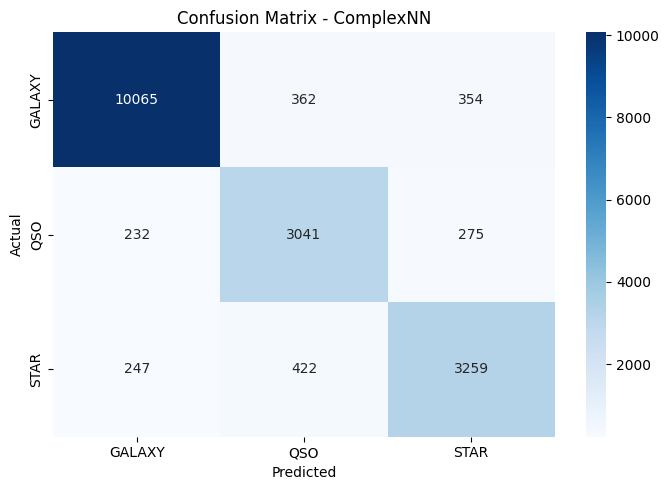

In [21]:
from stellar_classification.experiments.nn_runner import device
from stellar_classification.inference.predictor import evaluate_neural

# Miglior modello assoluto
best_model_row = final_sorted.iloc[0]

best_metrics = evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=device,
    model_name=f"{best_model_row['model']}"
)

# Stampa metriche
sc.print_metrics(best_metrics)

# Confusion matrix

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)

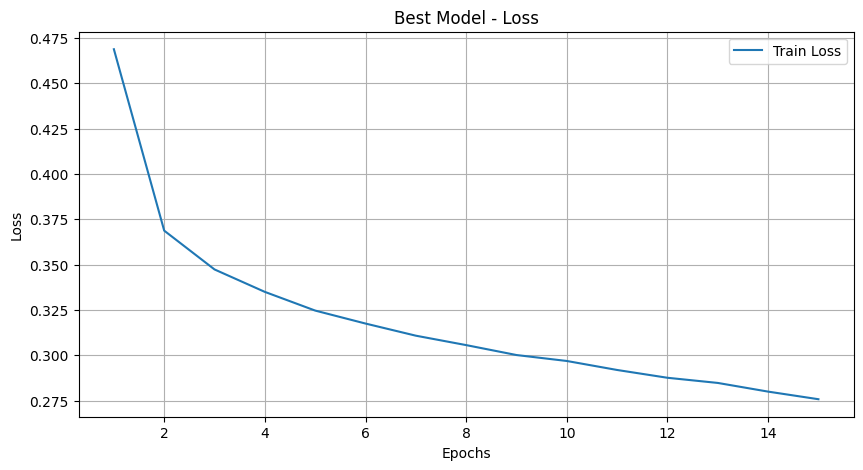

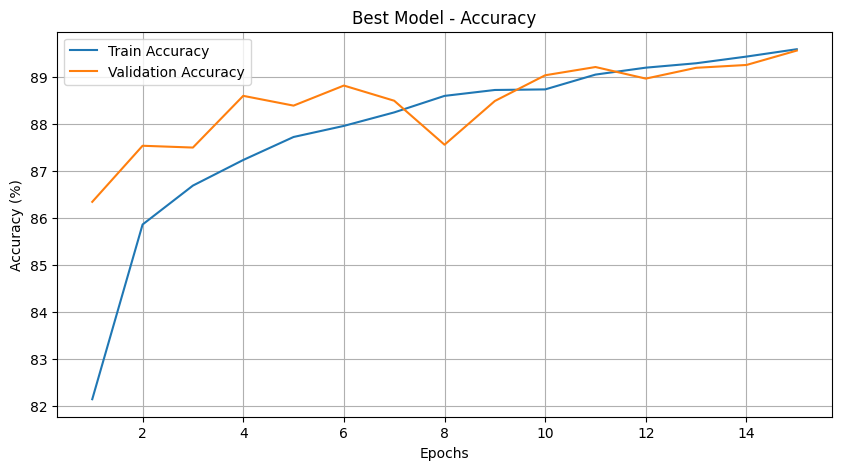

In [22]:
plot_training_history(best_model_row["history"], title="Best Model")

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257


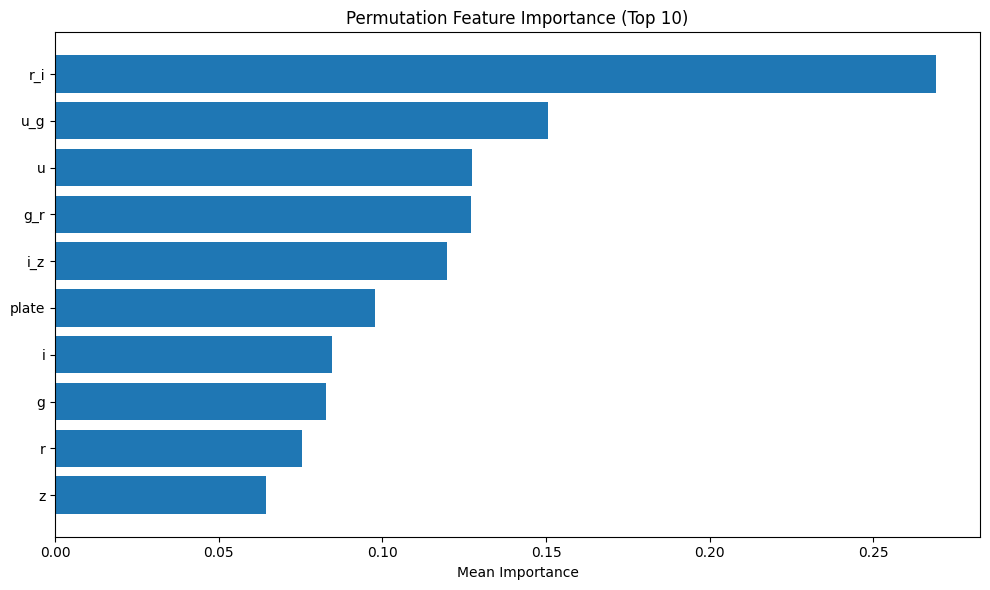

In [23]:
from stellar_classification.utils.wrapper import TorchModelWrapper

from stellar_classification.inference.predictor import compute_permutation_importance


wrapped_model = TorchModelWrapper(best_model_row["trained_model"], device)

imp = compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=10)

In [25]:
from stellar_classification.experiments.feature_ablation import run_feature_ablation

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=device,
    importance_scores=importance_scores,
    epochs=15
)

ablation_results


Best model: ComplexNN | lr=0.0001 | dropout=0.0

Training with top-1 features: ['r_i']
Epoch 1/15 | loss=0.8197 | train_acc=60.25% | val_acc=71.85%
Epoch 2/15 | loss=0.7996 | train_acc=62.22% | val_acc=71.17%
Epoch 3/15 | loss=0.7989 | train_acc=62.38% | val_acc=72.18%
Epoch 4/15 | loss=0.7985 | train_acc=62.48% | val_acc=72.77%
Epoch 5/15 | loss=0.7984 | train_acc=62.41% | val_acc=72.22%
Epoch 6/15 | loss=0.7982 | train_acc=62.56% | val_acc=71.15%
Epoch 7/15 | loss=0.7980 | train_acc=62.46% | val_acc=72.08%
Epoch 8/15 | loss=0.7980 | train_acc=62.52% | val_acc=72.01%
Epoch 9/15 | loss=0.7978 | train_acc=62.52% | val_acc=72.39%
Epoch 10/15 | loss=0.7980 | train_acc=62.55% | val_acc=73.18%
Epoch 11/15 | loss=0.7980 | train_acc=62.51% | val_acc=72.39%
Epoch 12/15 | loss=0.7979 | train_acc=62.52% | val_acc=72.03%
Epoch 13/15 | loss=0.7976 | train_acc=62.51% | val_acc=72.43%
Epoch 14/15 | loss=0.7977 | train_acc=62.54% | val_acc=72.56%
Epoch 15/15 | loss=0.7978 | train_acc=62.54% | val_ac

,n_features,features,val_f1,test_f1
0,1,[r_i],0.623199,0.629925
1,2,"[r_i, u_g]",0.792269,0.800444
2,3,"[r_i, u_g, u]",0.823086,0.828763
3,4,"[r_i, u_g, u, g_r]",0.838679,0.848319
4,5,"[r_i, u_g, u, g_r, i_z]",0.858121,0.864768
5,6,"[r_i, u_g, u, g_r, i_z, plate]",0.860747,0.863622
6,7,"[r_i, u_g, u, g_r, i_z, plate, i]",0.871593,0.873031
7,8,"[r_i, u_g, u, g_r, i_z, plate, i, g]",0.863454,0.866960
8,9,"[r_i, u_g, u, g_r, i_z, plate, i, g, r]",0.857436,0.861742
9,10,"[r_i, u_g, u, g_r, i_z, plate, i, g, r, z]",0.863532,0.864819


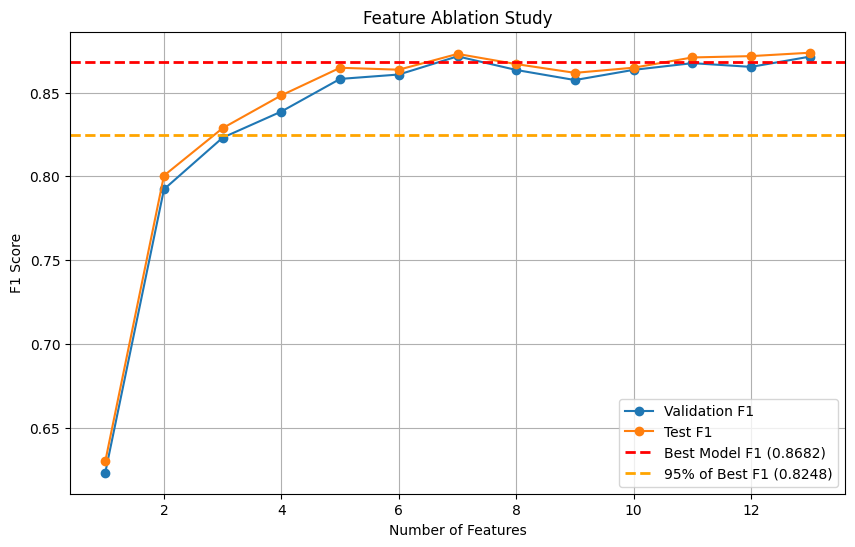

In [26]:
from stellar_classification.visualization.model_selection import plot_feature_ablation

best_val_f1 = final_sorted.iloc[0]["val_f1"]

plot_feature_ablation(
    ablation_results,
    best_val_f1=best_val_f1
)

In [27]:
from stellar_classification.experiments.feature_ablation import (
    get_feature_subset_threshold
)

best_subset = get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")


===== 95% FEATURE SUBSET =====
Target F1       : 0.8248
Reached F1      : 0.8387
N. features     : 4

Selected features:
 - r_i
 - u_g
 - u
 - g_r


In [29]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)

Relative performance: 96.60%


# PCA

         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)

PCA ENABLED
Original features: 13
PCA components: 13
Explained variance: 100.00%


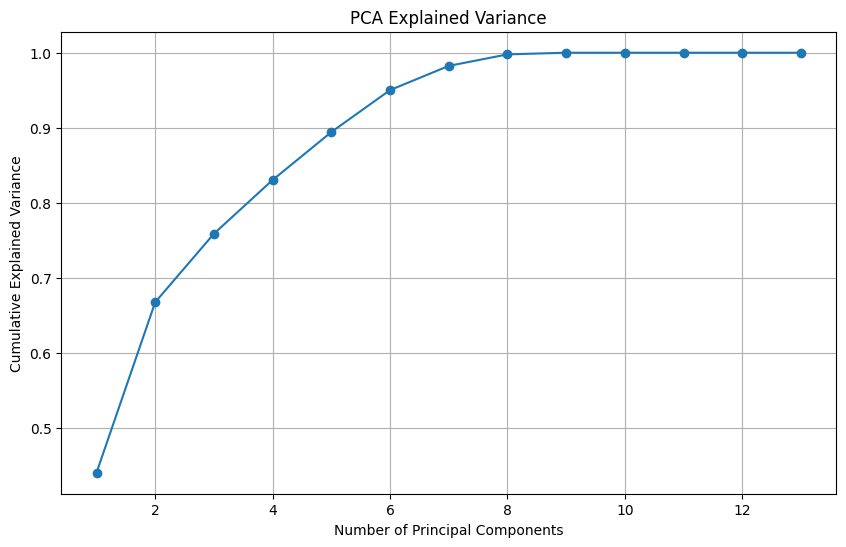

In [30]:
from stellar_classification.data.preprocessing import prepare_splits
from stellar_classification.experiments.pca_ablation import (
    plot_explained_variance
)

# ============================================================
# PCA preprocessing
# ============================================================

(
    X_train_pca,
    X_val_pca,
    X_test_pca,
    y_train_pca,
    y_val_pca,
    y_test_pca,
    label_encoder_pca,
    scaler_pca,
    feature_names_pca,
    pca,
) = prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True,

    # PCA
    apply_pca=True,
    n_components=None,
)

# Plot explained variance
plot_explained_variance(pca)

In [31]:
from stellar_classification.experiments.pca_ablation import (
    run_pca_ablation
)

# ============================================================
# Best model
# ============================================================

best_model_row = final_sorted.iloc[0]

# ============================================================
# PCA ablation
# ============================================================

pca_results = run_pca_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    best_model_row=best_model_row,

    num_classes=num_classes,
    device=device,

    component_list=list(range(1, X_train.shape[1] + 1)),

    epochs=15,
)

display(pca_results)


PCA Experiment | components=1
Explained variance: 41.73%
Epoch 1/15 | loss=0.9758 | train_acc=50.86% | val_acc=35.38%
Epoch 2/15 | loss=0.9587 | train_acc=52.17% | val_acc=38.03%
Epoch 3/15 | loss=0.9564 | train_acc=52.42% | val_acc=41.84%
Epoch 4/15 | loss=0.9555 | train_acc=52.49% | val_acc=40.49%
Epoch 5/15 | loss=0.9552 | train_acc=52.52% | val_acc=38.13%
Epoch 6/15 | loss=0.9552 | train_acc=52.61% | val_acc=39.88%
Epoch 7/15 | loss=0.9549 | train_acc=52.56% | val_acc=42.30%
Epoch 8/15 | loss=0.9548 | train_acc=52.47% | val_acc=44.97%
Epoch 9/15 | loss=0.9545 | train_acc=52.51% | val_acc=46.95%
Epoch 10/15 | loss=0.9543 | train_acc=52.64% | val_acc=44.70%
Epoch 11/15 | loss=0.9542 | train_acc=52.69% | val_acc=47.06%
Epoch 12/15 | loss=0.9542 | train_acc=52.59% | val_acc=41.57%
Epoch 13/15 | loss=0.9539 | train_acc=52.54% | val_acc=43.07%
Epoch 14/15 | loss=0.9540 | train_acc=52.60% | val_acc=45.18%
Epoch 15/15 | loss=0.9541 | train_acc=52.61% | val_acc=38.92%

PCA Experiment | com

,n_components,explained_variance,val_f1,test_f1
0,1,0.417260,0.394963,0.400335
1,2,0.659930,0.720846,0.717851
2,3,0.755961,0.743688,0.737848
3,4,0.833082,0.771576,0.768579
4,5,0.896748,0.792994,0.787758
5,6,0.951347,0.846626,0.849359
6,7,0.984690,0.849152,0.849650
7,8,0.997797,0.864768,0.866860
8,9,1.000000,0.862332,0.864795
9,10,1.000000,0.867792,0.872568


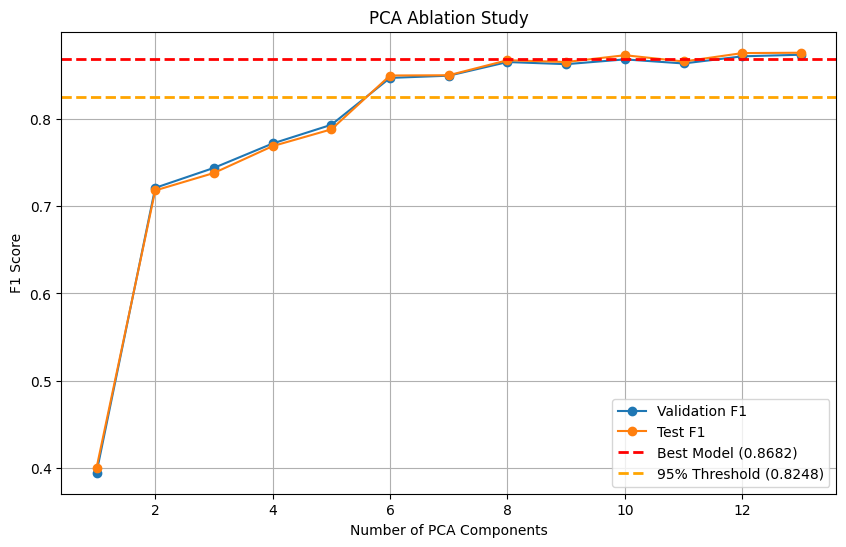

In [32]:
from stellar_classification.visualization.model_selection import (
    plot_pca_ablation
)

plot_pca_ablation(
    pca_results,
    best_val_f1=best_model_row["val_f1"],
)